# 05 — Feature exploration and feature engineering boilerplate

This notebook is a **template for understanding the project's features and adding new ones**. It covers:

1. **What's in the feature registry** — listing all registered features and where they're implemented.
2. **Feature distributions** — what each feature looks like after rank normalization (the headline L1 regression's preprocessing).
3. **Cross-sectional dispersion over time** — how much each feature varies across tickers on a given date. Features with too little cross-sectional spread can't produce a cross-sectional ranking signal.
4. **Pairwise correlation matrix** — the L1-stability prerequisite from the README's Discussion. The headline 9-feature panel has pairwise correlations typically below 0.3.
5. **Feature importance from a fitted L1 regression** — coefficients across walk-forward refits, showing which anomalies actually survive L1 selection.
6. **Feature importance from a fitted LightGBM** — gain-importance ranking, for the tree-ensemble baseline.
7. **How to add a new feature** — the registry pattern + a minimal example.

**Reading this notebook end-to-end takes ~3 minutes.** Running it end-to-end takes ~5 minutes (panel load + two model fits).


## 1. Setup


In [2]:
from __future__ import annotations

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [3]:
# Trigger feature registrations so the registry is populated.
import price_model.features.technical          # noqa: F401
import price_model.features.cross_features      # noqa: F401
import price_model.features.cross_sectional     # noqa: F401
import price_model.features.factor_loadings     # noqa: F401

from price_model.data.loaders import load_panel
from price_model.features.base import FEATURE_REGISTRY
from price_model.features.pipeline import build_feature_matrix, drop_warmup_rows
from price_model.models import build_model
from price_model.models.base import ModelConfig


## 2. What's in the feature registry

Features are registered via the `@register_feature` decorator in their source modules. Each feature is a callable `panel -> pl.DataFrame` that returns a single column. The registry is the source of truth for which features exist; experiment YAMLs reference features by their registered name.

The 41 features cluster into five families:

- **Technical (single-ticker time series)** — `momentum_*`, `return_*`, `vol_*`, `rsi_14`, `distance_52w_high`, `range_ratio`, etc.
- **Cross-features (cross-sectional, computed across tickers on each date)** — `cs_return_dispersion_20`, `vol_20_rank`, `momentum_60_rank`, etc.
- **Cross-sectional (sector-relative)** — `sector_relative_return_5d`, `momentum_60_sector_rel`, etc.
- **Factor loadings (rolling betas)** — `mkt_beta_60`, `hml_beta_60`, `smb_beta_60`, etc.
- **Microstructure** — `overnight_return_1d`, `intraday_return_1d`, `amihud_illiquidity_20`.


In [4]:
print(f'{len(FEATURE_REGISTRY)} features registered:')
for name in sorted(FEATURE_REGISTRY):
    print(f'  - {name}')


41 features registered:
  - abnormal_volume
  - amihud_illiquidity_20
  - beta_60
  - body_ratio
  - cma_beta_60
  - cs_return_dispersion_20
  - distance_52w_high
  - distance_ma_200
  - distance_ma_200_rank
  - hml_beta_60
  - hml_beta_x_hml_20d
  - idio_vol_20
  - intraday_return_1d
  - log_dollar_volume
  - max_return_21d
  - mkt_beta_60
  - mkt_beta_x_mkt_20d
  - mkt_beta_xs_dispersion
  - mom60_minus_dist_ma200
  - momentum_12_1
  - momentum_378
  - momentum_504
  - momentum_60
  - momentum_60_rank
  - momentum_60_sector_rel
  - momentum_756
  - overnight_return_1d
  - parkinson_vol_20
  - range_ratio
  - residual_return_5d
  - return_1d
  - return_5d
  - rmw_beta_60
  - rsi_14
  - sector_relative_return_5d
  - smb_beta_60
  - smb_beta_x_smb_20d
  - vol_20
  - vol_20_cs_min_dist
  - vol_20_rank
  - vol_ewm_20


## 3. Load the panel and build the headline 9-feature matrix

Use the same 9 features as the headline L1 regression (`lasso_elasso_pit_h21`). Apply rank normalization to match the headline recipe.


In [5]:
HEADLINE_FEATURES = [
    'momentum_12_1',
    'momentum_756',
    'return_1d',
    'vol_ewm_20',
    'idio_vol_20',
    'max_return_21d',
    'distance_52w_high',
    'log_dollar_volume',
    'beta_60',
]

# PIT-corrected S&P 500 panel.
panel = load_panel(universe='sp500_pit', start='2017-01-01', pit_filter=True)
print(f'Panel: {panel.height:,} rows, {panel["date"].n_unique():,} dates, '
      f'{panel["ticker"].n_unique():,} tickers')
print(f'Date range: {panel["date"].min()} → {panel["date"].max()}')


Panel: 1,113,352 rows, 2,369 dates, 599 tickers
Date range: 2017-01-03 → 2026-06-05


In [6]:
matrix = build_feature_matrix(
    panel,
    feature_names=HEADLINE_FEATURES,
    normalize_kind='rank',     # matches headline recipe
    target_horizon=21,         # 21-day forward excess return
)
matrix = drop_warmup_rows(matrix, HEADLINE_FEATURES).drop_nulls('y').sort('date')
print(f'Feature matrix: {matrix.height:,} rows × {matrix["date"].n_unique():,} dates × '
      f'{len(HEADLINE_FEATURES)} features + target')
matrix.head(10)


Feature matrix: 686,518 rows × 1,592 dates × 9 features + target


date,ticker,open,high,low,close,adj_close,volume,sector,momentum_12_1,momentum_756,return_1d,vol_ewm_20,idio_vol_20,max_return_21d,distance_52w_high,log_dollar_volume,beta_60,y
date,str,f64,f64,f64,f64,f64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2020-01-06,"""A""",84.0,84.82,83.599998,84.82,81.129616,1993200,"""Unknown""",0.470183,0.80303,0.590414,0.331155,0.146018,0.303965,0.772936,0.507625,0.653422,-0.017285
2020-01-06,"""AAL""",27.190001,27.49,27.08,27.32,27.21941,6105800,"""Unknown""",0.041284,0.032828,0.098039,0.976035,0.931416,0.786344,0.038991,0.505447,0.951435,0.048226
2020-01-06,"""AAP""",157.740005,158.889999,156.429993,156.800003,137.636459,880200,"""Unknown""",0.091743,0.136364,0.04793,0.729847,0.882743,0.764317,0.162844,0.411765,0.580574,-0.153426
2020-01-06,"""AAPL""",73.447502,74.989998,73.1875,74.949997,72.201424,118387200,"""Information Technology""",0.986239,0.977273,0.801743,0.54902,0.559735,0.570485,0.90367,1.0,0.637969,0.051144
2020-01-06,"""ABBV""",88.220001,89.620003,87.980003,89.400002,68.581177,6786600,"""Health Care""",0.144495,0.623737,0.797386,0.433551,0.320796,0.585903,0.821101,0.895425,0.690949,-0.036636
2020-01-06,"""ABT""",85.620003,86.360001,85.209999,86.339996,76.78624,5631700,"""Health Care""",0.561927,0.929293,0.699346,0.111111,0.303097,0.127753,0.669725,0.858388,0.326711,0.022273
2020-01-06,"""ACN""",208.270004,208.789993,206.809998,208.429993,189.333725,2841400,"""Information Technology""",0.818807,0.808081,0.20915,0.089325,0.274336,0.165198,0.715596,0.888889,0.339956,0.003297
2020-01-06,"""ADBE""",328.290009,333.910004,328.190002,333.709991,333.709991,1874700,"""Information Technology""",0.692661,1.0,0.718954,0.461874,0.681416,0.894273,0.899083,0.897603,0.392936,0.072549
2020-01-06,"""ADI""",116.25,117.32,115.610001,116.919998,104.650009,1979400,"""Information Technology""",0.791284,0.689394,0.102397,0.705882,0.393805,0.528634,0.454128,0.649237,0.89404,-0.020637


## 4. Feature distributions (rank-normalized)

After rank normalization within each date, every feature is on the same `[0, 1]` scale, with a flat marginal distribution across the cross-section. The interesting structure is in the **cross-sectional ordering**, not the marginal distribution. The histograms below confirm the rank normalization worked as expected.


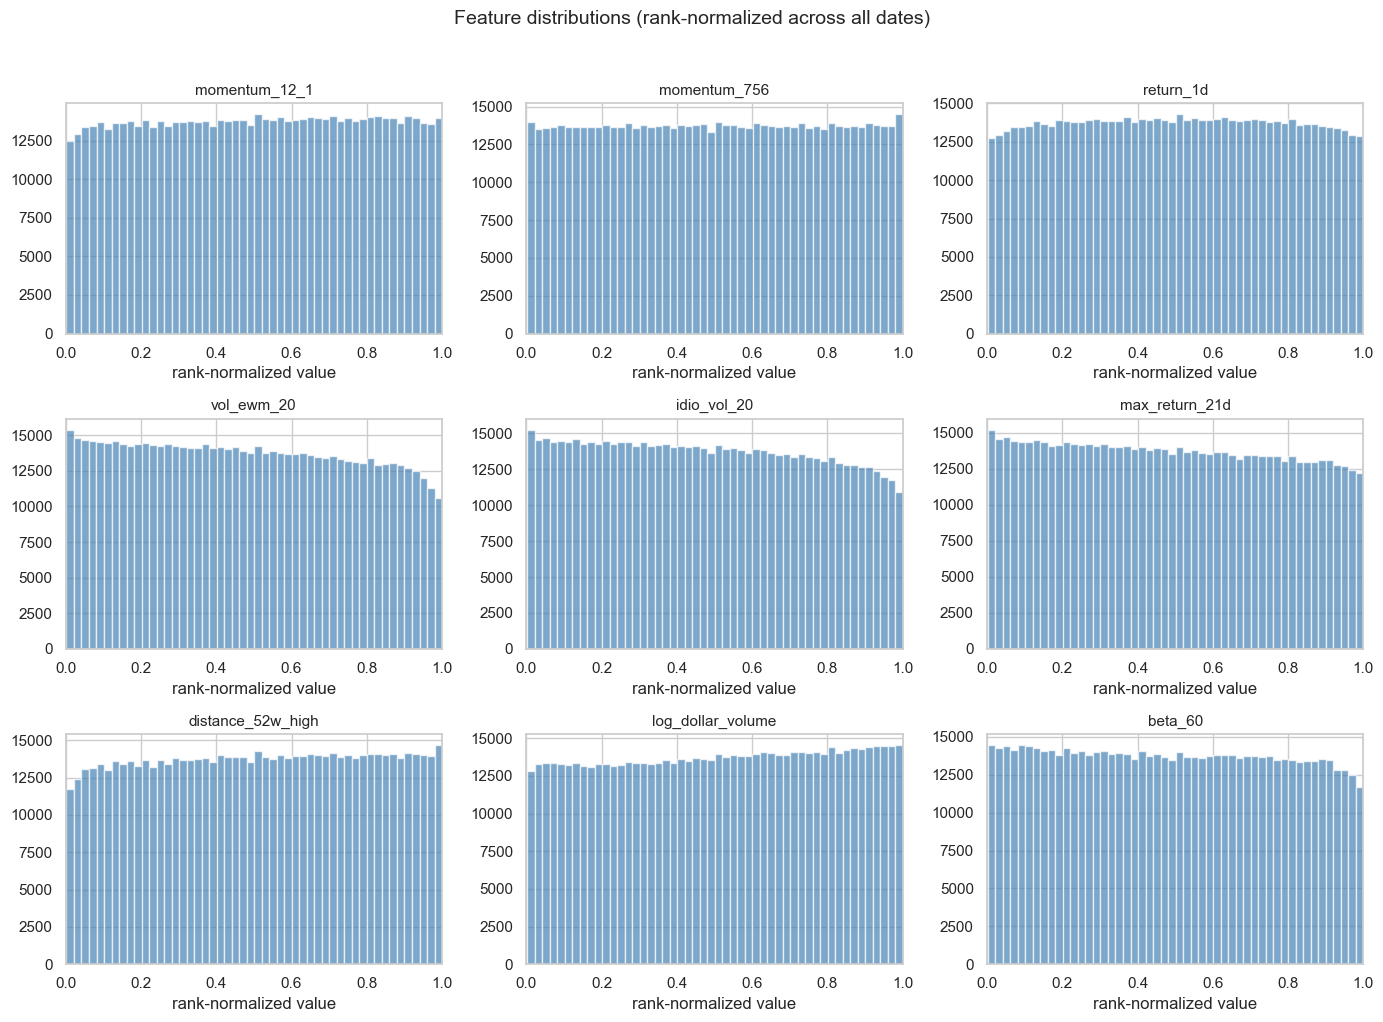

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, feat in zip(axes.flat, HEADLINE_FEATURES):
    vals = matrix[feat].drop_nulls().to_numpy()
    ax.hist(vals, bins=50, alpha=0.7, color='steelblue')
    ax.set_title(feat, fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_xlabel('rank-normalized value')
plt.suptitle('Feature distributions (rank-normalized across all dates)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 5. Cross-sectional dispersion over time

How much does each feature vary across tickers on a given date? Features with collapsing cross-sectional spread (e.g., everyone has roughly the same momentum) cannot produce a cross-sectional ranking signal that day.

Computed as the standard deviation of the **raw (pre-normalization)** feature across tickers, per date. For rank-normalized features the cross-sectional std is mechanically constant; the pre-normalization version is more informative for diagnosing 'is this feature actually saying anything today?'.


In [8]:
# Rebuild without normalization so we can see raw cross-sectional spread.
raw_matrix = build_feature_matrix(
    panel,
    feature_names=HEADLINE_FEATURES,
    normalize_kind='none',
    target_horizon=21,
)
raw_matrix = drop_warmup_rows(raw_matrix, HEADLINE_FEATURES).sort('date')
print(f'Raw matrix: {raw_matrix.height:,} rows')


Raw matrix: 697,205 rows


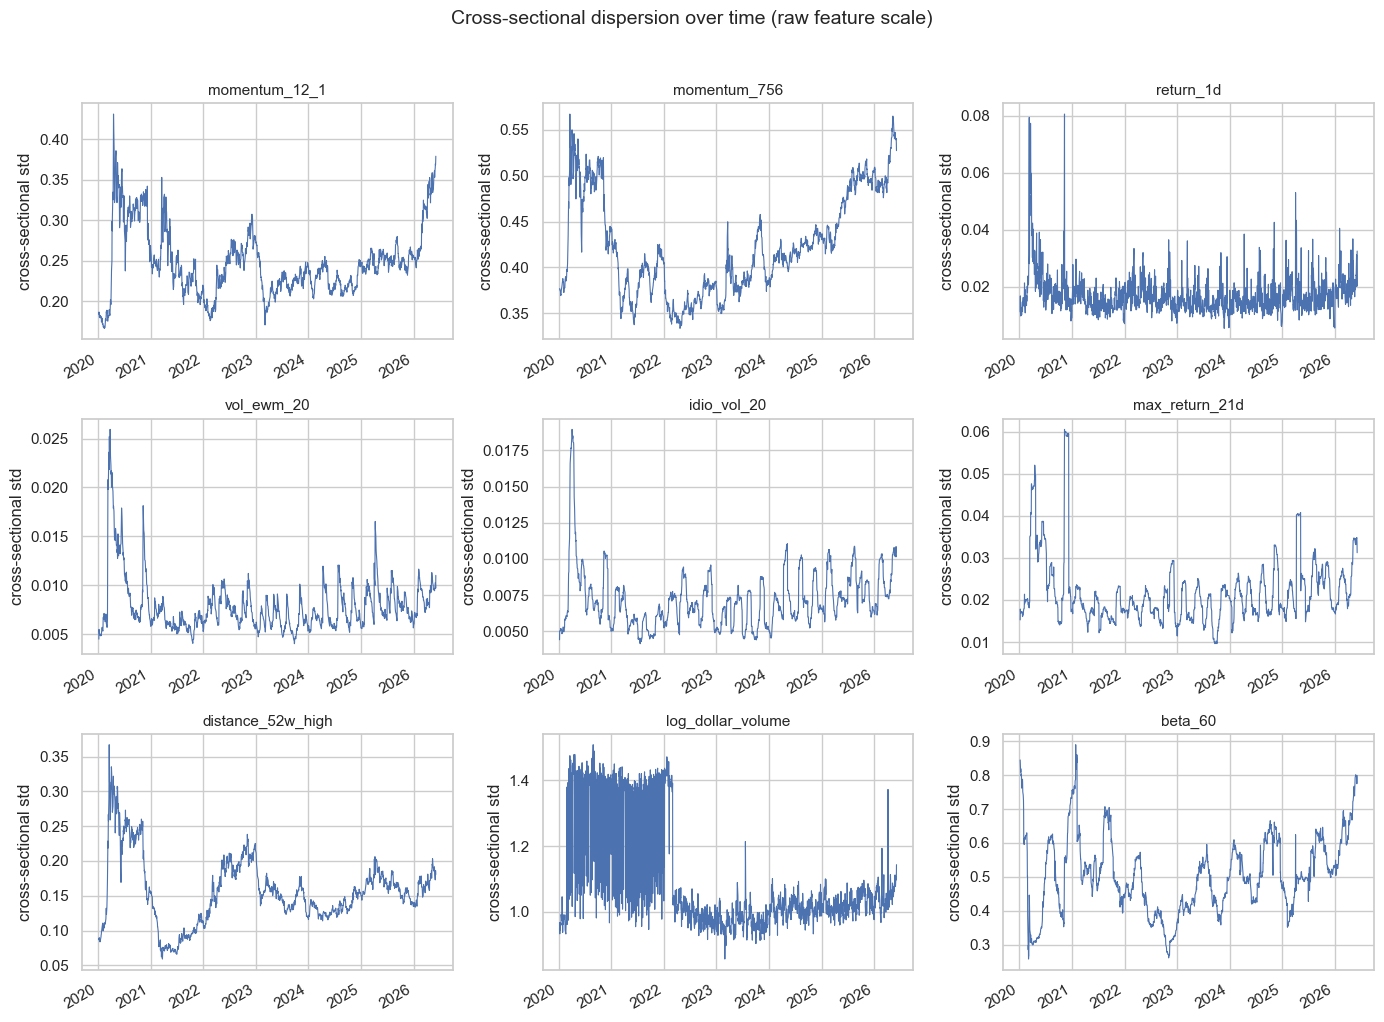

In [9]:
dispersion = (
    raw_matrix
    .group_by('date')
    .agg([pl.col(f).std().alias(f) for f in HEADLINE_FEATURES])
    .sort('date')
    .to_pandas()
    .set_index('date')
)
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, feat in zip(axes.flat, HEADLINE_FEATURES):
    dispersion[feat].plot(ax=ax, lw=0.8)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('cross-sectional std')
plt.suptitle('Cross-sectional dispersion over time (raw feature scale)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 6. Pairwise feature correlation matrix

The L1-stability prerequisite: features must span economically distinct mechanisms with low pairwise correlations. The README's Discussion section argues that the headline 9-feature panel works because its pairwise correlations are typically below 0.3. The pure-momentum panel (4 momentum factors) has correlations 0.5–0.8, which is why the same L1 recipe produces negative IC on that panel.

Below: rank-normalized features. The heatmap should be mostly pale — strong dark squares indicate redundancy.


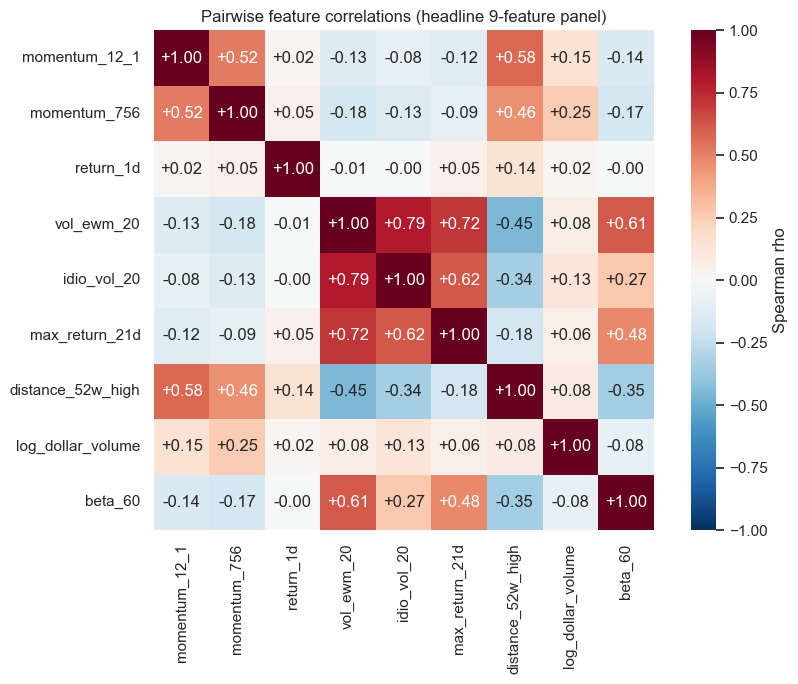

Pairs with |rho| > 0.5: 6 (out of 36 total pairs)


In [10]:
corr = matrix.select(HEADLINE_FEATURES).drop_nulls().to_pandas().corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, annot=True, fmt='+.2f', cmap='RdBu_r', vmin=-1, vmax=1,
    center=0, square=True, cbar_kws={'label': 'Spearman rho'}, ax=ax,
)
ax.set_title('Pairwise feature correlations (headline 9-feature panel)')
plt.tight_layout()
plt.show()

n_high = ((corr.abs() > 0.5) & (corr.abs() < 1.0)).sum().sum() // 2
print(f'Pairs with |rho| > 0.5: {n_high} (out of {len(HEADLINE_FEATURES) * (len(HEADLINE_FEATURES) - 1) // 2} total pairs)')


## 7. Feature importance from a fitted L1 regression

Fit a single Lasso model on the full training panel (pre-2025) and inspect the coefficients. In production, the walk-forward harness refits annually and the coefficients can shift between refits; this notebook shows the static snapshot for intuition.


In [11]:
# Train on data through end-2024 to keep 2025+ as out-of-sample.
train_matrix = matrix.filter(pl.col('date') < date(2025, 1, 1))
print(f'Train rows: {train_matrix.height:,}, dates: {train_matrix["date"].n_unique():,}')

cfg = ModelConfig(
    model_id='notebook_lasso',
    feature_cols=tuple(HEADLINE_FEATURES),
    target_col='y',
    params={'cv': 5, 'max_iter': 5000},
)
lasso = build_model('LassoCrossSectional', cfg)
lasso.fit(train_matrix)
print(f'CV-selected alpha: {lasso.selected_alpha():.6g}')


Train rows: 535,551, dates: 1,256
CV-selected alpha: 0.000442636


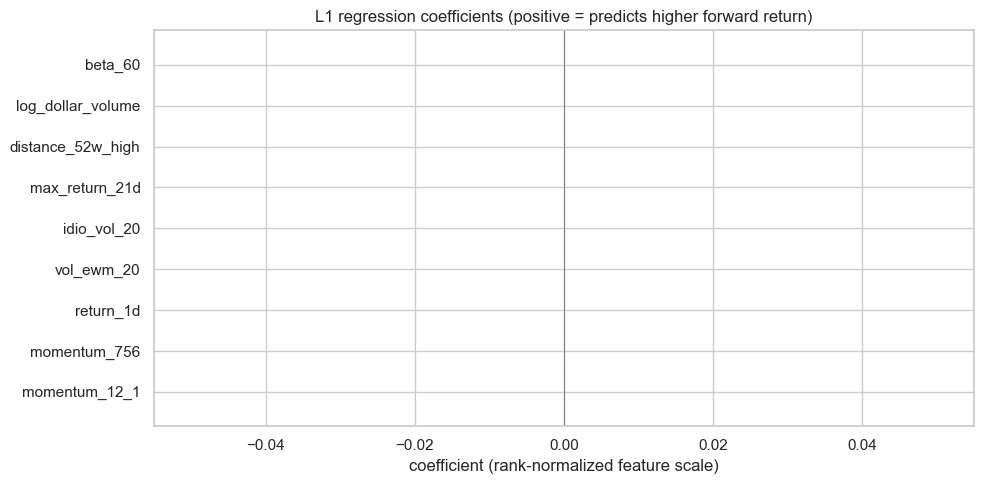

,feature,coefficient,abs_coef
0,momentum_12_1,0.0,0.0
1,momentum_756,0.0,0.0
2,return_1d,0.0,0.0
3,vol_ewm_20,0.0,0.0
4,idio_vol_20,0.0,0.0
5,max_return_21d,0.0,0.0
6,distance_52w_high,0.0,0.0
7,log_dollar_volume,0.0,0.0
8,beta_60,0.0,0.0


In [12]:
coefs = lasso.feature_importance()
coef_df = (
    pl.DataFrame({'feature': list(coefs.keys()), 'coefficient': list(coefs.values())})
    .with_columns(pl.col('coefficient').abs().alias('abs_coef'))
    .sort('abs_coef', descending=True)
    .to_pandas()
)
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'tomato' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('coefficient (rank-normalized feature scale)')
ax.set_title('L1 regression coefficients (positive = predicts higher forward return)')
plt.tight_layout()
plt.show()
coef_df


## 8. Feature importance from a fitted LightGBM

Trees rank features by gain-importance: the total reduction in the training loss attributable to splits on each feature. The headline finding in the Discussion section is that LightGBM's signal extraction on this 9-feature panel is consistently lower than the L1 regression's; the gain-importance distribution below shows which features the trees rely on most.

Uses default LightGBM HPs (no Optuna). Multi-seed averaging is skipped for notebook simplicity (one seed).


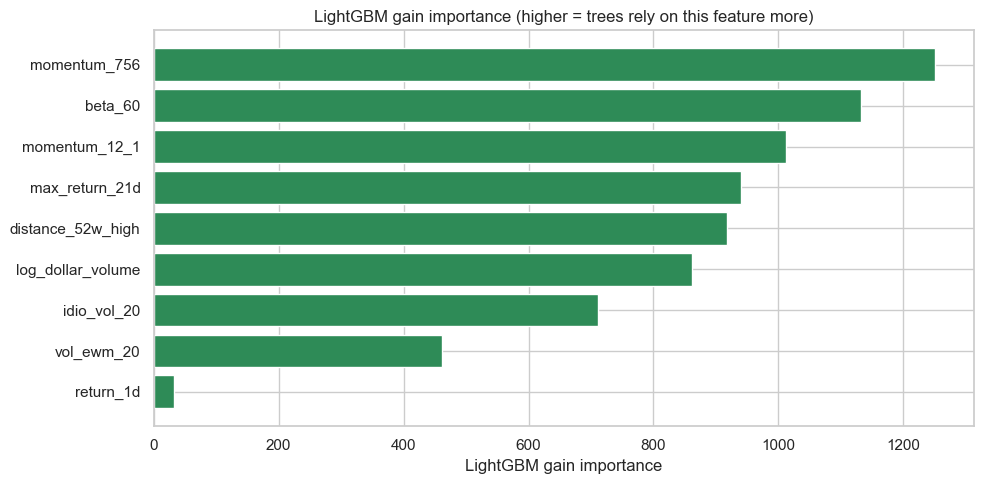

,feature,gain_importance
0,momentum_756,1250.656552
1,beta_60,1132.241058
2,momentum_12_1,1011.479227
3,max_return_21d,940.028774
4,distance_52w_high,917.307236
5,log_dollar_volume,861.400173
6,idio_vol_20,710.572892
7,vol_ewm_20,461.775146
8,return_1d,33.095896


In [13]:
lgbm_cfg = ModelConfig(
    model_id='notebook_lightgbm',
    feature_cols=tuple(HEADLINE_FEATURES),
    target_col='y',
    params={
        'learning_rate': 0.02,
        'num_leaves': 64,
        'min_data_in_leaf': 200,
        'n_estimators': 500,
        'seeds': [42],
    },
)
lgbm = build_model('LightGBMModel', lgbm_cfg)
lgbm.fit(train_matrix)

importances = lgbm.feature_importance()
imp_df = (
    pl.DataFrame({'feature': list(importances.keys()), 'gain_importance': list(importances.values())})
    .sort('gain_importance', descending=True)
    .to_pandas()
)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp_df['feature'], imp_df['gain_importance'], color='seagreen')
ax.invert_yaxis()
ax.set_xlabel('LightGBM gain importance')
ax.set_title('LightGBM gain importance (higher = trees rely on this feature more)')
plt.tight_layout()
plt.show()
imp_df


## 9. How to add a new feature

All features follow the registry pattern. To add a feature:

**Step 1 — Implement it in the appropriate module.** Single-ticker time-series → `src/price_model/features/technical.py`; cross-sectional → `src/price_model/features/cross_sectional.py`; rolling betas → `src/price_model/features/factor_loadings.py`.

**Step 2 — Decorate with `@register_feature`.** The decorator takes the feature name as a string. The function must accept a `polars.DataFrame` panel and return a single-column `polars.DataFrame` with the same `(date, ticker)` granularity.

**Step 3 — Verify lookahead safety.** The truncation-invariance test in `tests/test_leakage.py` runs automatically against every registered feature in CI. If the feature uses any future information, this test will fail.

**Step 4 — Reference in an experiment YAML.** Add the feature name to the `features:` list in a YAML under `config/experiments/`. The walk-forward harness will pick it up automatically.

Below is a minimal example — a 5-day skewness feature that captures whether a stock's recent return distribution is skewed positive or negative.


In [14]:
# Example: a 5-day skewness feature.
# This cell only shows the pattern — the actual feature should be added
# to src/price_model/features/technical.py with the @register_feature
# decorator, then referenced from a YAML config.

EXAMPLE_FEATURE_SOURCE = '''
# In src/price_model/features/technical.py:

from price_model.features.base import register_feature
import polars as pl

@register_feature("return_skew_20")
def return_skew_20(panel: pl.DataFrame) -> pl.DataFrame:
    """20-day rolling skewness of daily log returns per ticker.

    Positive skew = recent right tail (occasional big up days);
    negative skew = occasional big down days. Documented in the
    asset-pricing literature as a cross-sectional anomaly
    (Boyer-Mitton-Vorkink 2010, RFS 23(1)).
    """
    return panel.sort(["ticker", "date"]).with_columns(
        pl.col("adj_close").log().diff().over("ticker")
        .rolling_skew(window_size=20)
        .over("ticker")
        .alias("return_skew_20")
    ).select(["date", "ticker", "return_skew_20"])
'''
print(EXAMPLE_FEATURE_SOURCE)



# In src/price_model/features/technical.py:

from price_model.features.base import register_feature
import polars as pl

@register_feature("return_skew_20")
def return_skew_20(panel: pl.DataFrame) -> pl.DataFrame:
    """20-day rolling skewness of daily log returns per ticker.

    Positive skew = recent right tail (occasional big up days);
    negative skew = occasional big down days. Documented in the
    asset-pricing literature as a cross-sectional anomaly
    (Boyer-Mitton-Vorkink 2010, RFS 23(1)).
    """
    return panel.sort(["ticker", "date"]).with_columns(
        pl.col("adj_close").log().diff().over("ticker")
        .rolling_skew(window_size=20)
        .over("ticker")
        .alias("return_skew_20")
    ).select(["date", "ticker", "return_skew_20"])



## Next steps

- **Run the feature audit script** (`scripts/audit_lightgbm_features.py`) for a more detailed cross-feature analysis on a fitted model.
- **Inspect the pure-momentum Lasso failure mode** with `scripts/inspect_momentum_lasso_coefficients.py` — shows how L1 cancels on a heavily-correlated feature panel.
- **Add a new feature** following section 9, then add it to a YAML config in `config/experiments/` and run via the CLI.
